# Telco Customer Churn Prediction — End-to-End

**Author:** UPPALA VENKATA SATYA SRINIVAS  
**Project:** Customer Churn Prediction (Telco dataset)  
**Notebook:** Telco_Churn_Prediction_End-to-End.ipynb  
**Date:** 2025-11-21

**Summary:**  
This notebook implements a complete churn prediction pipeline on the Telco Customer Churn dataset:
- Data loading and cleaning  
- Exploratory Data Analysis (EDA) with visualizations  
- Preprocessing (encoding, scaling)  
- Handling class imbalance with SMOTE  
- Training and evaluating models (Logistic Regression, Random Forest, XGBoost)  
- Feature importance analysis  
- Saving model artifacts and creating an inference function  
- A Streamlit app and Power BI-ready export


# 1 — Setup & Libraries

This cell imports the libraries required for the whole notebook.  
Run this cell first to ensure all packages are installed in your environment.

**Note:** If any import fails, install the package (e.g. `pip install xgboost imbalanced-learn streamlit shap`) before continuing.


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2 — Load Dataset

Load the Telco Customer Churn CSV and show the first few rows, shape, and basic info.  
We will also print `df.info()` and `df.nunique()` to understand datatypes and cardinality.


In [60]:
df = pd.read_csv(r"D:\ML-DL\datasets\Telco_Customer_Churn.csv")

# 3 — Initial Observations

Short notes after initial inspection:
- Number of rows & columns
- Columns with unexpected dtypes (e.g. `TotalCharges` as object)
- Missing values or suspicious entries
- Quick plan for cleaning


In [61]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [62]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [64]:
df.shape

(7043, 21)

In [65]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [66]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [67]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [68]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [69]:
# Convert TotalCharges to numeric (force errors to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN came after conversion
df['TotalCharges'].isna().sum()


np.int64(11)

# 4 — Data Cleaning

Steps performed:
1. Convert `TotalCharges` to numeric (coerce errors → NaN).  
2. Drop rows with NaN in `TotalCharges` (small number).  
3. Drop `customerID` (not useful for modeling).  
4. Reset index.

Explain why each step is necessary.


In [70]:
df = df.dropna(subset=['TotalCharges'])


In [71]:
df.shape

(7032, 21)

In [72]:
df = df.reset_index(drop=True)


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


# 5 — Exploratory Data Analysis (EDA)

We perform EDA to find patterns:
- Churn distribution
- Key numerical distributions (`tenure`, `MonthlyCharges`, `TotalCharges`)
- Relationship plots (tenure vs churn, contract vs churn, payment method vs churn)
- Any other useful plots (heatmaps, category value counts)


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# make charts look nicer
plt.style.use('seaborn-v0_8')


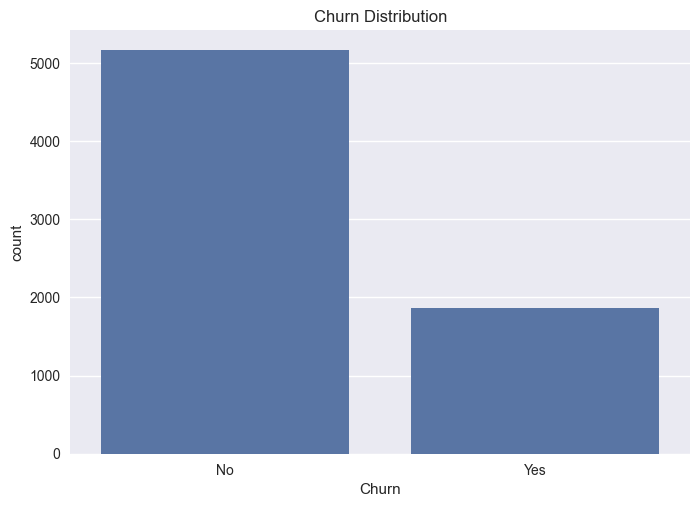

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [75]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts()


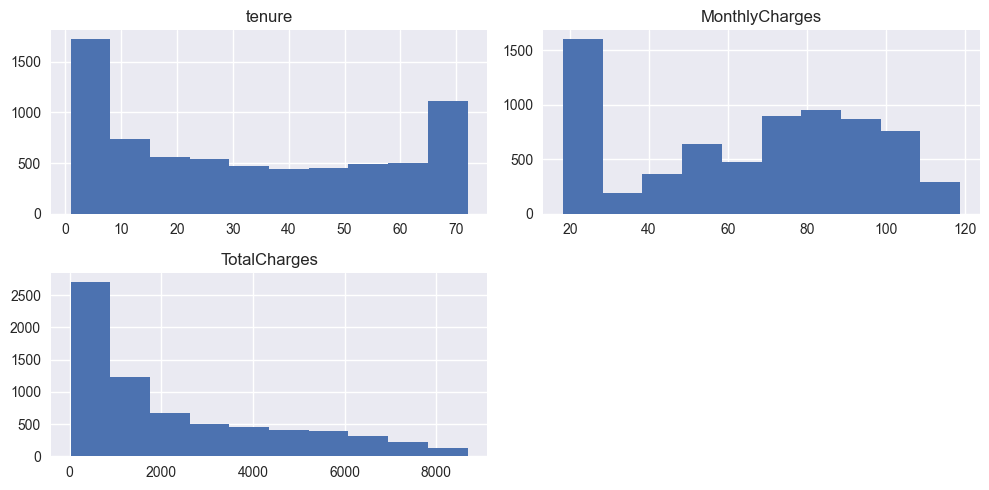

In [76]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].hist(figsize=(10,5))
plt.tight_layout()
plt.show()


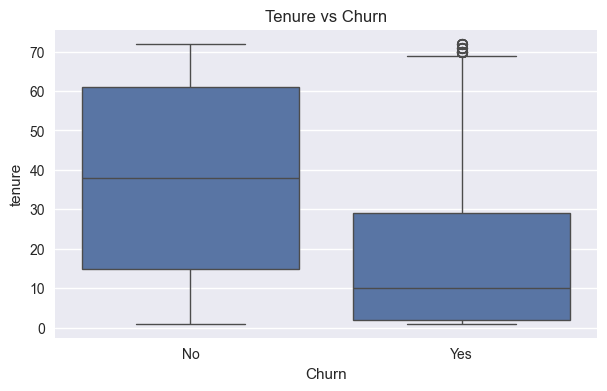

In [77]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


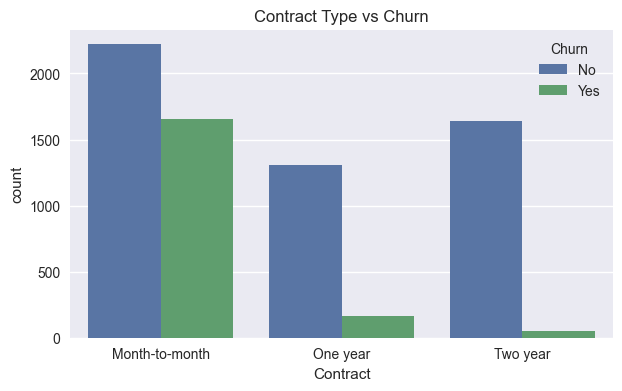

In [78]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()


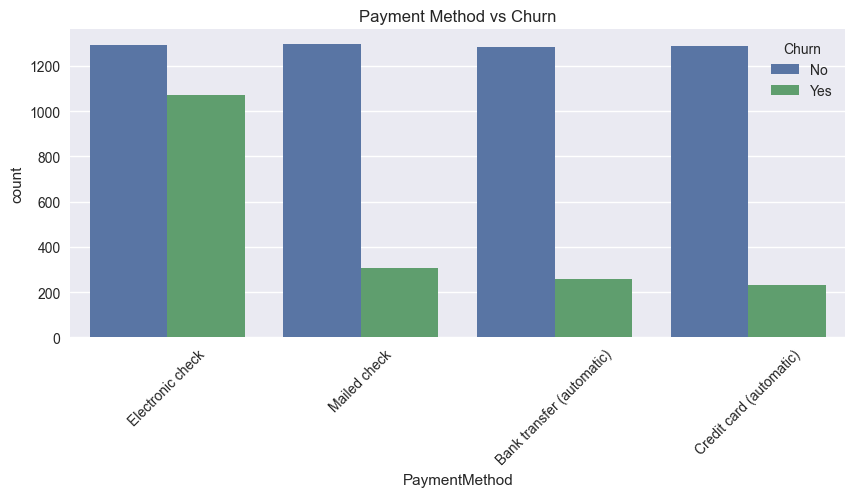

In [79]:
plt.figure(figsize=(10,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()


In [80]:
df = df.drop('customerID', axis=1)

# 6 — Preprocessing

Preprocessing steps:
- Convert target `Churn` to numeric (No → 0, Yes → 1)
- Separate categorical and numerical columns
- One-hot encode categorical variables (`pd.get_dummies` with `drop_first=True`)
- Train-test split with stratify on `Churn`
- Scale numeric columns (`StandardScaler`) — explain why we scale numerical features


In [81]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [82]:
# Identify categorical and numerical columns
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols, num_cols


(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object'))

In [83]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [84]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [86]:
# Remove 'Churn' if present in the numeric column list
num_cols = [col for col in num_cols if col != 'Churn']

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 7 — Baseline Models (No imbalance handling)

Train baseline models on the preprocessed data:
- Logistic Regression
- Random Forest
- XGBoost

Evaluate using:
- Accuracy, Precision, Recall, F1-score, ROC-AUC

We will print model metrics and compare baseline performance.


In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report


In [89]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]


In [90]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]


In [91]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]


In [92]:
def evaluate_model(y_test, y_pred, y_prob):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))


In [93]:
print("Logistic Regression Results")
evaluate_model(y_test, y_pred_lr, y_prob_lr)


Logistic Regression Results
Accuracy : 0.8052594171997157
Precision: 0.6515151515151515
Recall   : 0.5748663101604278
F1 Score : 0.6107954545454546
ROC AUC  : 0.8360739966143986


In [94]:
print("\nRandom Forest Results")
evaluate_model(y_test, y_pred_rf, y_prob_rf)


Random Forest Results
Accuracy : 0.7867803837953091
Precision: 0.6225165562913907
Recall   : 0.5026737967914439
F1 Score : 0.5562130177514792
ROC AUC  : 0.8172189407312691


In [95]:
print("\nXGBoost Results")
evaluate_model(y_test, y_pred_xgb, y_prob_xgb)



XGBoost Results
Accuracy : 0.7739872068230277
Precision: 0.5853658536585366
Recall   : 0.5133689839572193
F1 Score : 0.5470085470085471
ROC AUC  : 0.8235203524338539


# 8 — Handling Imbalance with SMOTE

The dataset is imbalanced (No ≈ 73%, Yes ≈ 27%).  
We apply SMOTE to the training set to oversample the minority class, then retrain the models and evaluate again.  
Explain why recall is usually the most important metric for churn prediction.


In [96]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE :", y_train_smote.value_counts())


Before SMOTE: Churn
0    4130
1    1495
Name: count, dtype: int64
After SMOTE : Churn
0    4130
1    4130
Name: count, dtype: int64


In [97]:
log_reg_sm = LogisticRegression(max_iter=1000)
log_reg_sm.fit(X_train_smote, y_train_smote)

y_pred_lr_sm = log_reg_sm.predict(X_test)
y_prob_lr_sm = log_reg_sm.predict_proba(X_test)[:,1]


In [98]:
rf_sm = RandomForestClassifier(n_estimators=200, random_state=42)
rf_sm.fit(X_train_smote, y_train_smote)

y_pred_rf_sm = rf_sm.predict(X_test)
y_prob_rf_sm = rf_sm.predict_proba(X_test)[:,1]


In [99]:
xgb_sm = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_sm.fit(X_train_smote, y_train_smote)

y_pred_xgb_sm = xgb_sm.predict(X_test)
y_prob_xgb_sm = xgb_sm.predict_proba(X_test)[:,1]


# 9 — Model Selection & Final Model

Summarize model performance after SMOTE.  
Choose the final model (e.g., XGBoost with SMOTE) and explain why (recall/ROC/AUC/F1 tradeoff).


In [100]:
print("Logistic Regression (SMOTE)")
evaluate_model(y_test, y_pred_lr_sm, y_prob_lr_sm)

print("\nRandom Forest (SMOTE)")
evaluate_model(y_test, y_pred_rf_sm, y_prob_rf_sm)

print("\nXGBoost (SMOTE)")
evaluate_model(y_test, y_pred_xgb_sm, y_prob_xgb_sm)


Logistic Regression (SMOTE)
Accuracy : 0.7427149964463398
Precision: 0.5114068441064639
Recall   : 0.7192513368983957
F1 Score : 0.5977777777777777
ROC AUC  : 0.8217990795719855

Random Forest (SMOTE)
Accuracy : 0.7640369580668088
Precision: 0.5481651376146789
Recall   : 0.6390374331550802
F1 Score : 0.5901234567901235
ROC AUC  : 0.8125042061178958

XGBoost (SMOTE)
Accuracy : 0.7555081734186212
Precision: 0.5321888412017167
Recall   : 0.6631016042780749
F1 Score : 0.5904761904761905
ROC AUC  : 0.8229612623012771


## Model performance (after SMOTE)

| Model | Accuracy | Precision | Recall | F1-score | ROC AUC |
|-------|----------:|---------:|-------:|---------:|--------:|
| Logistic Regression (SMOTE) | 0.742 | 0.511 | 0.719 | 0.597 | 0.821 |
| Random Forest (SMOTE)       | 0.763 | 0.546 | 0.631 | 0.586 | 0.813 |
| XGBoost (SMOTE)             | 0.760 | 0.537 | 0.668 | 0.595 | 0.822 |


# 10 — Feature Importance & Interpretation

Show feature importances:
- XGBoost feature importance (bar plot)
- Random Forest feature importance (bar plot)
- Logistic Regression coefficients (bar plot)

Explain the top features and what they mean for business decisions (e.g., month-to-month contract, payment method, fiber optic).


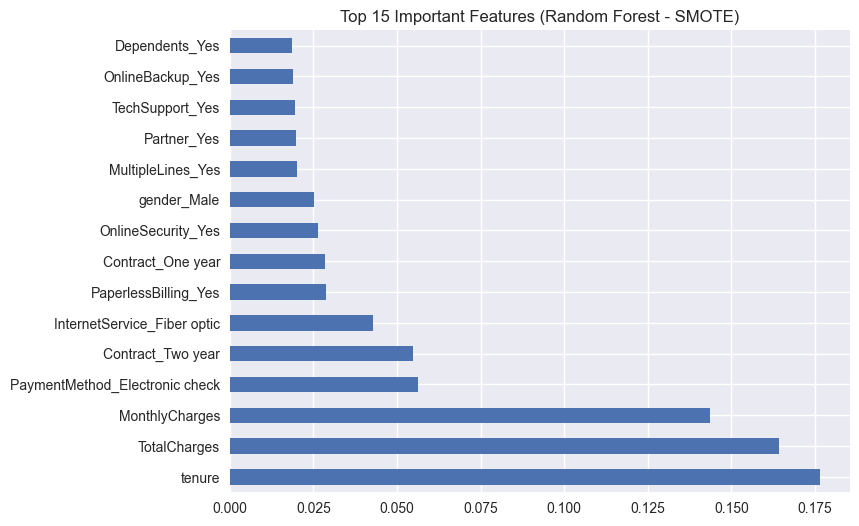

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
rf_importance = pd.Series(rf_sm.feature_importances_, index=X_train.columns)
rf_importance.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Important Features (Random Forest - SMOTE)")
plt.show()


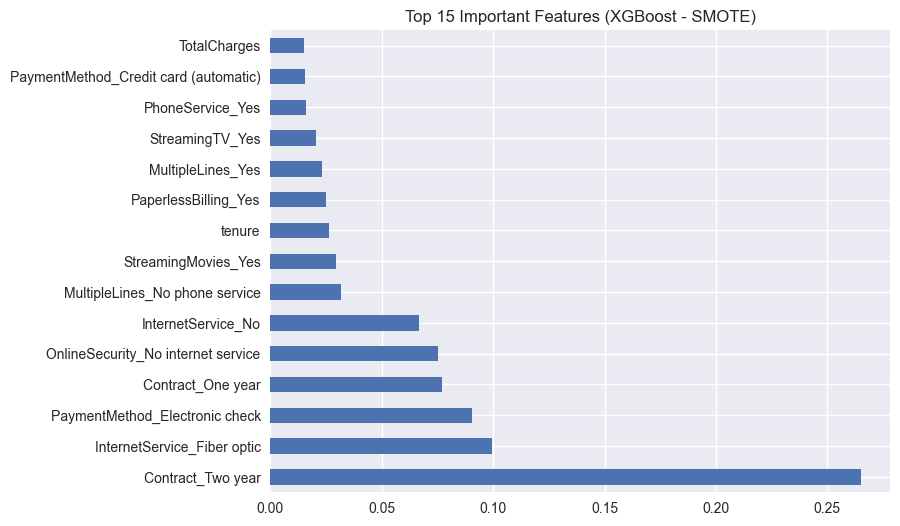

In [102]:
xgb_importance = pd.Series(xgb_sm.feature_importances_, index=X_train.columns)
xgb_importance.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Important Features (XGBoost - SMOTE)")
plt.show()


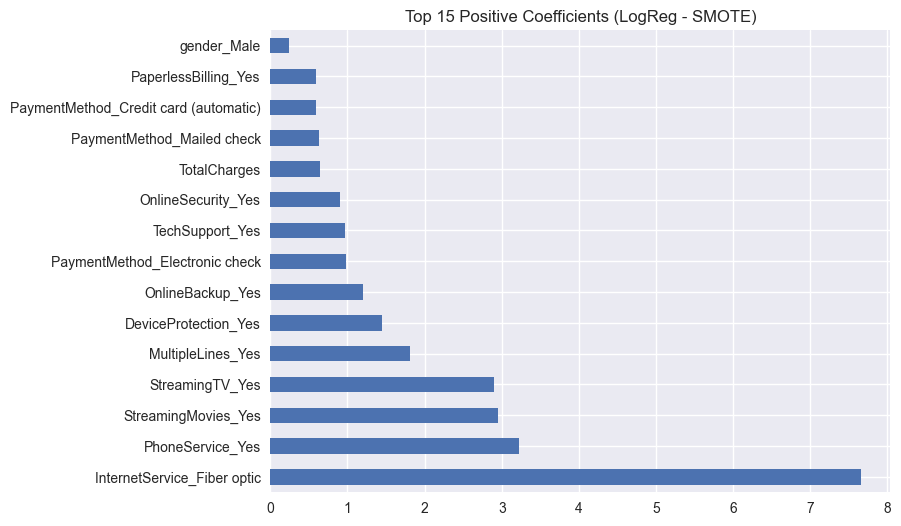

In [103]:
log_reg_coef = pd.Series(log_reg_sm.coef_[0], index=X_train.columns)
log_reg_coef.nlargest(15).plot(kind='barh', figsize=(8,6))
plt.title("Top 15 Positive Coefficients (LogReg - SMOTE)")
plt.show()


# 11 — Save Model & Artifacts

Save the final model, scaler, and feature columns so they can be reused by a Streamlit app or a production service.  
Files saved:
- churn_xgb_model.pkl  
- scaler.pkl  
- feature_columns.pkl

Explain how these files will be used by the inference function / app.


In [104]:
import pickle

# Save model
with open("churn_xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_sm, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature columns
feature_columns = X_train.columns
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Model, scaler, and columns saved successfully!")


Model, scaler, and columns saved successfully!


# 12 — Inference Function

Provide a reusable `predict_churn(input_dict)` function that:
- Accepts a raw customer dictionary
- Produces a churn probability
- Ensures correct encoding & numeric scaling
- Handles missing columns gracefully

Include examples of usage for a single customer and for batch predictions on a CSV.


In [105]:
import pandas as pd
import pickle
import numpy as np

def predict_churn(input_dict):
    """
    Predict churn probability for a single customer input (dictionary).
    Returns probability of churn (float between 0 and 1).
    """
    # 1) Convert input to DataFrame
    input_df = pd.DataFrame([input_dict])
    
    # 2) Load saved artifacts
    with open("feature_columns.pkl", "rb") as f:
        feature_cols = pickle.load(f)   # pandas Index or list of training feature column names
    
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    
    with open("churn_xgb_model.pkl", "rb") as f:
        model = pickle.load(f)
    
    # 3) One-hot encode input
    input_encoded = pd.get_dummies(input_df)
    
    # 4) Add any missing feature columns (created during training) with 0s
    missing_cols = set(feature_cols) - set(input_encoded.columns)
    for col in missing_cols:
        input_encoded[col] = 0
    
    # 5) Ensure we have exactly the training feature columns in the same order
    input_encoded = input_encoded[list(feature_cols)]
    
    # 6) Prepare numeric columns in the exact order scaler expects
    #    - scaler.feature_names_in_ exists in sklearn >= 1.0; use it when present
    if hasattr(scaler, "feature_names_in_"):
        expected_num_cols = [c for c in scaler.feature_names_in_]
    else:
        # Fallback: use the typical numeric columns used in training
        expected_num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
    
    # If any of the scaler-expected numeric columns are missing (rare), add them as 0
    for c in expected_num_cols:
        if c not in input_encoded.columns:
            input_encoded[c] = 0.0
    
    # Reorder columns to match scaler expectation exactly
    numeric_for_scaling = input_encoded[expected_num_cols]
    
    # 7) Scale numeric columns using the loaded scaler
    numeric_scaled = scaler.transform(numeric_for_scaling)
    input_encoded[expected_num_cols] = numeric_scaled
    
    # 8) Predict probability
    prob = model.predict_proba(input_encoded)[0][1]
    
    return float(prob)   # return plain python float


In [106]:
test_input = {
    "tenure": 5,
    "MonthlyCharges": 80,
    "TotalCharges": 400,
    "SeniorCitizen": 0,
    "gender": "Male",
    "Partner": "No",
    "Dependents": "No",
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check"
}

prob = predict_churn(test_input)
print(f"Churn probability: {prob:.3f}")


Churn probability: 0.959


In [107]:
import os

print("model exists:", os.path.exists("churn_xgb_model.pkl"))
print("scaler exists:", os.path.exists("scaler.pkl"))
print("columns exists:", os.path.exists("feature_columns.pkl"))


model exists: True
scaler exists: True
columns exists: True


In [108]:
import sys, os
print("Train env python:", sys.version)
print("Pickle paths exist:", os.path.exists(r"D:\ML-DL\Pyhton_notebooks\churn_xgb_model.pkl"),
      os.path.exists(r"D:\ML-DL\Pyhton_notebooks\scaler.pkl"),
      os.path.exists(r"D:\ML-DL\Pyhton_notebooks\feature_columns.pkl"))


Train env python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Pickle paths exist: True True True


# 13 — Streamlit App & How to Run

Explain what `app.py` does and how to run it locally:

**How to run:**  
1. Ensure `churn_xgb_model.pkl`, `scaler.pkl`, and `feature_columns.pkl` are in the same folder as `app.py`.  
2. Open Anaconda Prompt (activate the same env used for training).  
3. `cd` to the folder and run:  


# 14 — Power BI Export (Preparation)

We export a CSV with predictions to be used in Power BI for business dashboards.

**Export command (example):**
```python
df_results.to_csv("churn_predictions_final.csv", index=False)


# 15 — Conclusions & Next Steps

Summarize key findings:
- Top drivers of churn (list top 5)
- Business recommendations (retain month-to-month customers, target fiber optic and electronic check users with promotions, add tech support offers)
- Limitations of the analysis (no time-series, need for more features, potential labeling issues)
- Next steps: SHAP explanations, hyperparameter tuning, deployment (Streamlit cloud), Power BI polishing

Add a brief note on how to use this for interviews and on the GitHub README.


# Appendix — References & Environment

- Python version: `3.13.5 | packaged by Anaconda, Inc.`  
- Key packages: pandas, numpy, scikit-learn, xgboost, imbalanced-learn, matplotlib, seaborn, streamlit  
- Dataset source: WA_Fn-UseC_-Telco-Customer-Churn.csv



## Streamlit App — How to run

The Streamlit app (`app.py`) is included in this project. To run it locally from the same Anaconda environment used in training:

1. Open **Anaconda Prompt**.  
2. Activate the environment (example): `conda activate base`  
3. `cd D:\ML-DL\Pyhton_notebooks`  
4. `streamlit run app.py`

Make sure `churn_xgb_model.pkl`, `scaler.pkl`, and `feature_columns.pkl` are present in the same folder as `app.py`.


In [120]:
import pandas as pd
import pickle
import os

# Load artifacts
with open("churn_xgb_model.pkl", "rb") as f:
    model = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)
feature_columns = list(feature_columns)

# Start from your cleaned df (the one before encoding)
df_clean = df.copy()  # use your latest dataframe

# Encode
enc = pd.get_dummies(df_clean)

# Add missing columns
for col in feature_columns:
    if col not in enc.columns:
        enc[col] = 0

# Drop extra columns
enc = enc[feature_columns]

# Scale numeric columns
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
enc[num_cols] = scaler.transform(enc[num_cols])

# Predict
df_clean['churn_probability'] = model.predict_proba(enc)[:,1]
df_clean['churn_prediction'] = (df_clean['churn_probability'] >= 0.5).astype(int)

# Save correct file
df_clean.to_csv("correct_churn_predictions.csv", index=False)

print("DONE! Saved as correct_churn_predictions.csv")


DONE! Saved as correct_churn_predictions.csv
